In [1]:
import sys
sys.path.insert(0, "/pscratch/sd/s/suryad/Ocean_Emulator/src")
sys.path.insert(0, "/pscratch/sd/s/suryad/Ocean_Emulator")

import torch
import xarray as xr
import matplotlib.pyplot as plt
from models.corrector import OceanHeatCorrector
from constants import TensorMap, INPT_VARS, EXTRA_VARS
from datasets import InferenceDataset
from utils.data import extract_wet_mask, Normalize
import numpy as np
from einops import rearrange
from utils.device import using_gpu
from functools import partial
from aggregator.metrics import area_weighted_sum


In [84]:
# Initialize TensorMap singleton
# tensor_map = TensorMap.init_instance("3D_all", "3D_all")
tensor_map = TensorMap.get_instance()

# Load the actual dataset
data = xr.open_zarr("/pscratch/sd/s/suryad/data/cm4_piControl_ocean_200yr_full_chunked.zarr")

# Load area weights
area_weights = torch.from_numpy(
    xr.open_zarr("/pscratch/sd/s/suryad/data/areacello.zarr")
    .to_array()
    .to_numpy()
)

area_weighted_func = partial(
            area_weighted_sum, area_weights=area_weights
        )

# Load means and stds for normalization
data_mean = xr.open_dataset(
    "/pscratch/sd/s/suryad/data/2024-11-12-cm4-piControl-ocean-200yr-dataset-stats/centering.nc",
    engine="netcdf4",
)
data_std = xr.open_dataset(
    "/pscratch/sd/s/suryad/data/2024-11-12-cm4-piControl-ocean-200yr-dataset-stats/scaling-full-field.nc",
    engine="netcdf4",
)

# Setup parameters
hist = 1
inputs = INPT_VARS["3D_all"]
extra_inputs = EXTRA_VARS["3D_all"]
outputs = INPT_VARS["3D_all"]

# Extract wet mask
wet, wet_surface = extract_wet_mask(data, outputs, hist)
wet_without_hist, _ = extract_wet_mask(data, outputs, 0)

# Initialize normalizer
# normalize = Normalize.init_instance(
#     data_mean,
#     data_std,
#     inputs,
#     extra_inputs,
#     outputs,
#     wet_without_hist,
# )
normalize = Normalize.get_instance()

# Create dataset
dataset = InferenceDataset(
    data,
    inputs,
    extra_inputs,
    outputs,
    wet,
    wet_surface,
    hist,
    long_rollout=True
)

RHO_0 = 1025.0
CP_SW = 3850.0
N_seconds = 5 * 24 * 60 * 60  # 5 day average
dz = tensor_map.dz

thetao_idx = tensor_map.OUT_VAR_3D_IDX["thetao"]
hfds_idx = tensor_map.INPT_BOUNDARY_IDX["hfds"]

if using_gpu():
    thetao_idx = thetao_idx.cuda()
    hfds_idx = hfds_idx.cuda()
    dz = dz.cuda()


In [85]:
output_channels = len(tensor_map.outputs)

def _rearrange_fts( fts):
    return rearrange(fts, "n (hist c) h w -> (n hist) c h w", hist=hist + 1)

def _rearrange_fts_with_boundary( fts ):
    fts_input = fts[:, : (hist + 1) * output_channels]
    fts_input = rearrange(
        fts_input, "n (hist c) h w -> (n hist) c h w", hist=hist + 1
    )

    fts_boundary = fts[:, (hist + 1) * output_channels :]
    fts_boundary = rearrange(
        fts_boundary, "n (hist c) h w -> (n hist) c h w", hist=hist + 1
    )
    return fts_input, fts_boundary

def _inv_rearrange_fts( fts ):
    return rearrange(fts, "(n hist) c h w -> n (hist c) h w", hist=hist + 1)

def _unnormalize_fts_outputs( fts ):
    # Corrector is run in float64 to avoid precision loss
    fts = fts.to(torch.float64)
    return normalize.unnormalize_tensor_outputs(fts)

def _normalize_fts_outputs( fts ):
    fts = normalize.normalize_tensor_outputs(fts)
    return fts.to(torch.float32)

def _unnormalize_fts_inputs(
        fts , fts_boundary 
) :
    # Corrector is run in float64 to avoid precision loss
    fts = fts.to(torch.float64)
    fts_boundary = fts_boundary.to(torch.float64)
    fts = normalize.unnormalize_tensor_inputs(fts)
    fts_boundary = normalize.unnormalize_tensor_boundary(fts_boundary)

    return fts, fts_boundary

In [86]:
def forward(fts_input_boundary, fts):
    fts_input_boundary = fts_input_boundary.detach()

    fts = _rearrange_fts(fts)
    fts = _unnormalize_fts_outputs(fts)

    fts_input, fts_boundary = _rearrange_fts_with_boundary(fts_input_boundary)
    fts_input, fts_boundary = _unnormalize_fts_inputs(fts_input, fts_boundary)

    # The input and output mapping of the variables are the same
    T_input = fts_input[:, thetao_idx]  # (batch, depth, lat, lon)
    T_pred = fts[:, thetao_idx]

    # Extract the boundary variables
    surface_heat_flux = fts_boundary[:, hfds_idx].squeeze(1)

    # Compute heat content per layer
    HC_t0 = RHO_0 * CP_SW * T_input * dz.view(1, -1, 1, 1)
    HC_t1 = RHO_0 * CP_SW * T_pred * dz.view(1, -1, 1, 1)

    # Column integrated heat content
    total_HC_t0 = torch.sum(HC_t0, dim=1)
    total_HC_t1 = torch.sum(HC_t1, dim=1)

    # Sum over depth to get total heat content
    global_HC_t0 = area_weighted_func(total_HC_t0)  # (batch,) [J]
    global_HC_t1 = area_weighted_func(total_HC_t1)

    # Expected change in heat content from surface flux
    dHC_expected = (
        area_weighted_func(surface_heat_flux) * N_seconds
    )  # [J]

    HC_correct_ratio = (global_HC_t0 + dHC_expected) / global_HC_t1
    HC_t1_corrected = HC_t1 * HC_correct_ratio.view(-1, 1, 1, 1)

    T_corrected = HC_t1_corrected / (
        RHO_0 * CP_SW * dz.view(1, -1, 1, 1)
    )

    global_HC_t1_corrected = area_weighted_func(HC_t1_corrected.sum(dim=1))
    fts[:, thetao_idx] = T_corrected

    fts = _normalize_fts_outputs(fts)
    fts = _inv_rearrange_fts(fts)

    return fts, HC_t1_corrected, global_HC_t1_corrected, global_HC_t1, global_HC_t0, dHC_expected


In [143]:

inp = dataset.__getitem__(0)[0].cuda()

expected_heat = []
predicted_heat_without_correction = []
predicted_heat_with_correction = []
for i in range(250):
    print(i)
    pred = inp[:,:dataset.initial_prognostic.shape[1]].cuda() + torch.randn_like(dataset.initial_prognostic).cuda()
    inp, HC_t1_corrected, global_HC_t1_corrected, global_HC_t1, global_HC_t0, dHC_expected = forward(inp, pred)
    inp = dataset.merge_prognostic_and_boundary(inp, i)
    expected_heat.extend((global_HC_t0 + dHC_expected).cpu().numpy().tolist())
    predicted_heat_without_correction.extend(global_HC_t1.cpu().numpy().tolist())
    predicted_heat_with_correction.extend(global_HC_t1_corrected.cpu().numpy().tolist())
    

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249


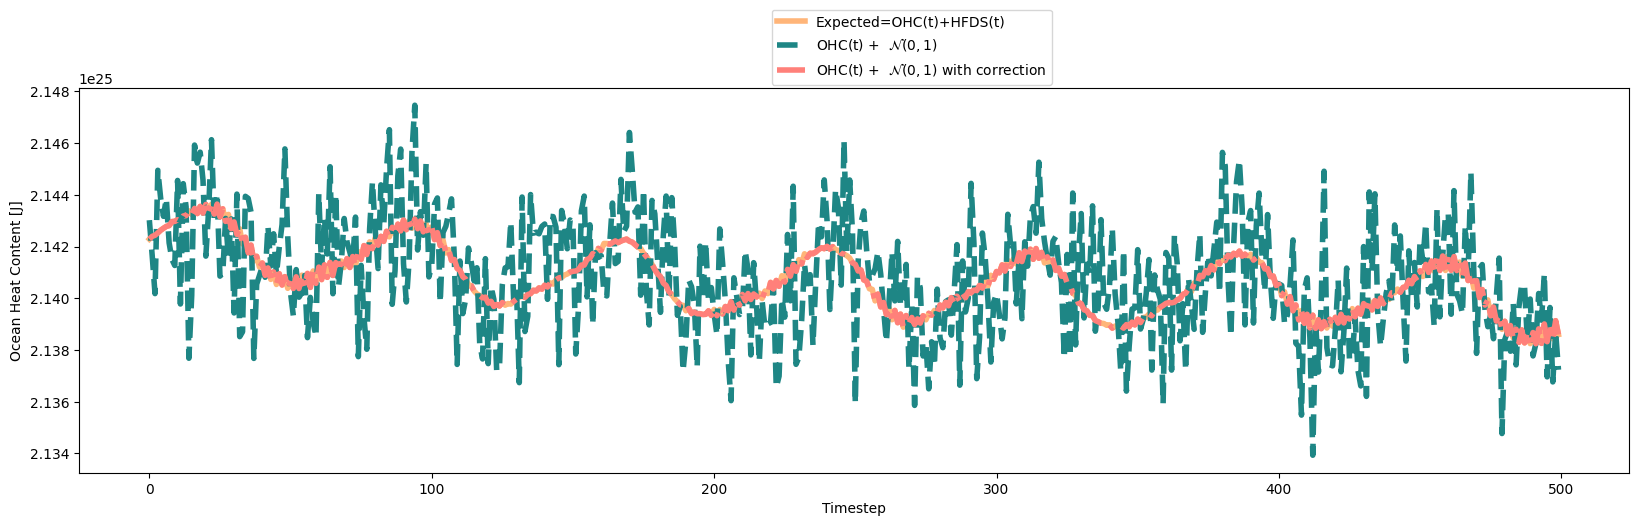

In [144]:
import matplotlib.pyplot as plt

datas= [expected_heat, predicted_heat_without_correction, predicted_heat_with_correction]
labels = ["Expected=OHC(t)+HFDS(t)", r"OHC(t) +  $\mathcal{N}(0,1)$", r"OHC(t) +  $\mathcal{N}(0,1)$ with correction"]
clist = ["#ffb579", "#1e8685", "#ff807a"]
fig, ax = plt.subplots(1, 1, figsize=(20, 5))
for gg,d in enumerate(datas):
    lw=4
    ls=['-','--','-.',':'][gg%4]
    plt.plot(d,label=labels[gg], c=clist[gg], linestyle=ls, linewidth=lw)

ax.set_ylabel('Ocean Heat Content [J]')
ax.set_xlabel('Timestep')
fig.legend(bbox_to_anchor=(0.615, 1.05), ncols=1)
plt.savefig('sanity_check_rollout', bbox_inches="tight", dpi=600)



In [121]:

pred = (dataset.initial_prognostic + torch.randn_like(dataset.initial_prognostic)).cuda()
expected_heat = []
predicted_heat_without_correction = []
predicted_heat_with_correction = []
for i in range(250):
    print(i)
    inp = dataset.__getitem__(i)[0].cuda()
    pred = (dataset.initial_prognostic + torch.randn_like(dataset.initial_prognostic)).cuda()
    # pred = (dataset.__getitem__(i)[1]).cuda()
    _, HC_t1_corrected, global_HC_t1_corrected, global_HC_t1, global_HC_t0, dHC_expected = forward(inp, pred)
    
    expected_heat.extend((global_HC_t0 + dHC_expected).cpu().numpy().tolist())
    predicted_heat_without_correction.extend(global_HC_t1.cpu().numpy().tolist())
    predicted_heat_with_correction.extend(global_HC_t1_corrected.cpu().numpy().tolist())
    

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249


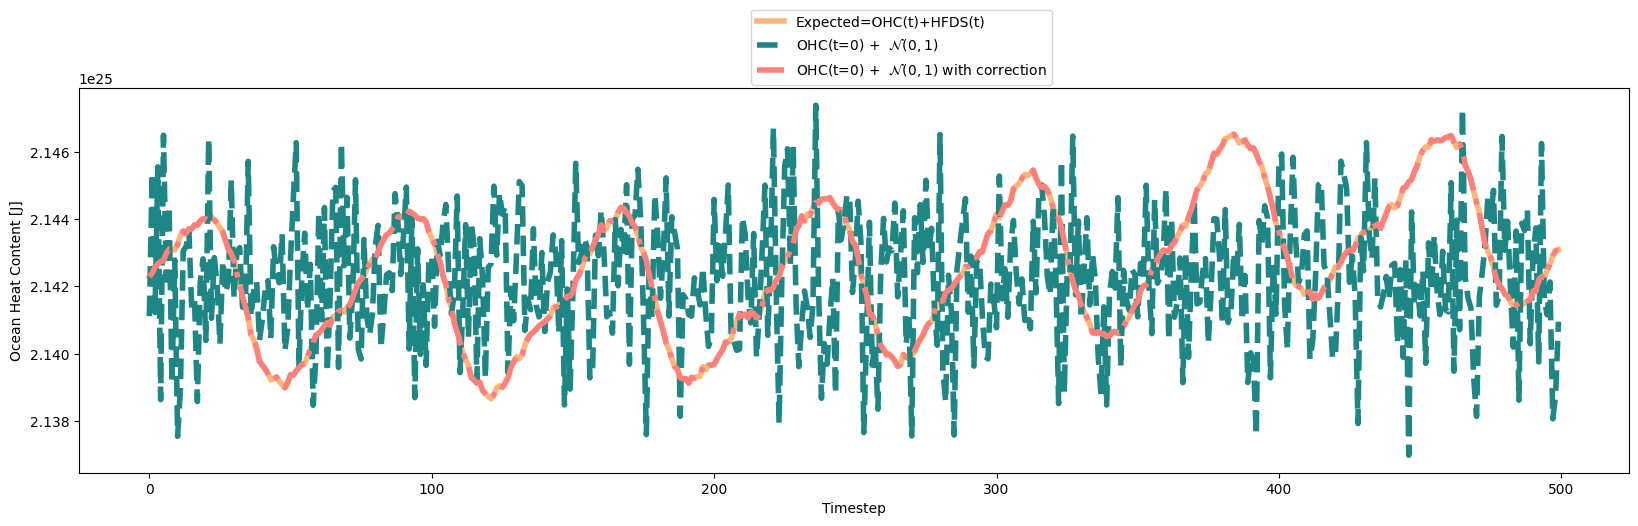

In [133]:
import matplotlib.pyplot as plt

datas= [expected_heat, predicted_heat_without_correction, predicted_heat_with_correction]
labels = ["Expected=OHC(t)+HFDS(t)", r"OHC(t=0) +  $\mathcal{N}(0,1)$", r"OHC(t=0) +  $\mathcal{N}(0,1)$ with correction"]
clist = ["#ffb579", "#1e8685", "#ff807a"]
fig, ax = plt.subplots(1, 1, figsize=(20, 5))
for gg,d in enumerate(datas):
    lw=4
    ls=['-','--','-.',':'][gg%4]
    plt.plot(d,label=labels[gg], c=clist[gg], linestyle=ls, linewidth=lw)

ax.set_ylabel('Ocean Heat Content [J]')
ax.set_xlabel('Timestep')
fig.legend(bbox_to_anchor=(0.615, 1.05), ncols=1)
plt.savefig('sanity_check_rand_inp', bbox_inches="tight", dpi=600)



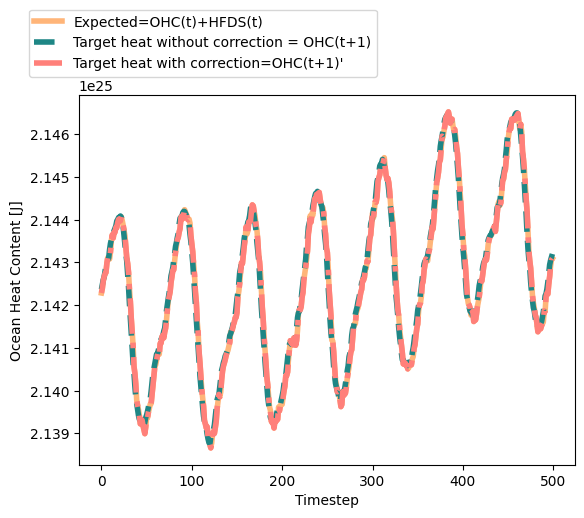

In [115]:
import matplotlib.pyplot as plt

datas= [expected_heat, predicted_heat_without_correction, predicted_heat_with_correction]
labels = ["Expected=OHC(t)+HFDS(t)", "Target heat without correction = OHC(t+1)", "Target heat with correction=OHC(t+1)'"]
clist = ["#ffb579", "#1e8685", "#ff807a"]
for gg,d in enumerate(datas):
    lw=4
    ls=['-','--','-.',':'][gg%4]
    plt.plot(d,label=labels[gg], c=clist[gg], linestyle=ls, linewidth=lw)

plt.ylabel('Ocean Heat Content [J]')
plt.xlabel('Timestep')
plt.legend(bbox_to_anchor=(0.615, 1.25), ncols=1)
plt.savefig('', bbox_inches="tight", dpi=600)



### Test

In [40]:
import torch
import numpy as np
from torch import nn

# Constants for seawater
RHO_0 = 1025.0  # Reference density of seawater [kg/m³]
CP_SW = 3850.0  # Specific heat capacity of seawater [J/kg/C]

# Need to unnormalize
class OceanHeatFixer(nn.Module):
    def __init__(self):
        super().__init__()
        self.N_seconds = 5 * 24 * 60 * 60  # 5 day average

    def forward(self, inputs):
        """
        Args:
            inputs: dict containing:
                T_input: Temperature at t0 [°C] (batch, depth, lat, lon)
                T_pred: Predicted temperature at t1 [°C]
                S_input: Salinity at t0 [PSU]
                S_pred: Predicted salinity at t1 [PSU]
                U_pred: Predicted zonal velocity [m/s]
                V_pred: Predicted meridional velocity [m/s]
                SSH_pred: Predicted sea surface height [m]
                dz: Layer thicknesses [m]
                surface_heat_flux: Net surface heat flux [W/m²] (positive = into ocean)
        """
        # Unpack inputs
        T_input = inputs['T_input']  # (batch, depth, lat, lon)
        T_pred = inputs['T_pred']
        dz = inputs['dz']  # (depth,)
        surface_heat_flux = inputs['surface_heat_flux']  # (batch, lat, lon)
S
        # t_ref = torch.mean(T_input)
        
        # Compute heat content per layer
        # HC = ρ * Cp * T * dz [J/m²]
        HC_t0 = RHO_0 * CP_SW * (T_input) * dz.view(1, -1, 1, 1)
        HC_t1 = RHO_0 * CP_SW * (T_pred) * dz.view(1, -1, 1, 1)
        
        # Sum over depth to get total heat content - these need to be area weighted
        total_HC_t0 = HC_t0.sum(dim=(1,2,3))  # (batch,) [J]
        total_HC_t1 = HC_t1.sum(dim=(1,2,3))

        # Expected change in heat content from surface flux - these need to be area weighted
        dHC_expected = surface_heat_flux.sum(dim=(1,2)) * self.N_seconds  # [J]

        # Compute correction ratio 
        HC_correct_ratio = ((total_HC_t0 + dHC_expected) / total_HC_t1)
        
        # Correcting heat content
        HC_t1_corrected = HC_t1 * HC_correct_ratio.unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)
        
        # Correct Temperature
        T_corrected = HC_t1_corrected / (RHO_0 * CP_SW * dz.view(1, -1, 1, 1))
    
        
        return T_corrected

In [ ]:
def test_ocean_heat_fixer():
    # Create test grid
    batch_size = 2
    depth = 19
    lat = 180
    lon = 360
    
    # Create sample inputs
    dz = torch.tensor([i*10.0 for i in range(1,20)])  # Layer thicknesses [m]
    # dz = dz/dz.sum()
    inputs = {
        'T_input': torch.randn((batch_size, depth, lat, lon), dtype=torch.float32)+35,  # °C
        'T_pred': torch.randn(batch_size, depth, lat, lon, dtype=torch.float32)+35,   # °C
        'S_input': torch.randn(batch_size, depth, lat, lon, dtype=torch.float32),  # PSU
        'S_pred': torch.randn(batch_size, depth, lat, lon, dtype=torch.float32),   # PSU
        'U_pred': torch.randn(batch_size, depth, lat, lon, dtype=torch.float32),          # m/s
        'V_pred': torch.randn(batch_size, depth, lat, lon, dtype=torch.float32),          # m/s
        'SSH_pred': torch.randn(batch_size, lat, lon, dtype=torch.float32),               # m
        'dz': dz,
        'surface_heat_flux': torch.randn(batch_size, lat, lon, dtype=torch.float32),  # W/m²
    }
    
    # Initialize fixer
    fixer = OceanHeatFixer()
    
    # Get corrected temperature
    T_corrected = fixer.forward(inputs)
    
    # Verify conservation
    for b in range(batch_size):
        # Calculate initial heat content
        HC_t0 = (RHO_0 * CP_SW * inputs['T_input'][b] * dz.view(1, -1, 1, 1)).sum()

        # Calculate initial heat content
        HC_t1 = (RHO_0 * CP_SW * inputs['T_pred'][b] * dz.view(1, -1, 1, 1)).sum()
        
        # Calculate final heat content
        HC_t1_corrected = (RHO_0 * CP_SW * T_corrected[b] * dz.view(1, -1, 1, 1)).sum()
        
        # Expected change from surface flux
        dHC_expected = (inputs['surface_heat_flux'][b]).sum() * fixer.N_seconds
        
        # Check conservation
        print("dHC_expected: ", dHC_expected)
        print("HC_t0: ", HC_t0)
        print("HC_t1: ", HC_t1)
        print("HC_t1 corrected: ", HC_t1_corrected)
        print("HC_t1- HC_t0 - dHC_expected", HC_t1- HC_t0 - dHC_expected)
        print("HC_t1_corrected- HC_t0 - dHC_expected", HC_t1_corrected- HC_t0 - dHC_expected)
        print("((HC_t1_corrected- HC_t0) - dHC_expected)/dHC_expected%", ((HC_t1_corrected- HC_t0) - dHC_expected)*100/(dHC_expected))
        assert torch.abs(HC_t1_corrected- HC_t0 - dHC_expected) < 1e-1, \
            f"Heat not conserved at b={b}, Error: {HC_t1_corrected- HC_t0 - dHC_expected})"
    
    print("Tests passed!")
    
    # Print example correction for one column
    b, i, j = 0, 0, 0
    print("\nExample correction for one water column:")
    print(f"Initial temperatures: {inputs['T_pred'][b, :, i, j].numpy()}")
    print(f"Corrected temperatures: {T_corrected[b, :, i, j].numpy()}")
    print(f"Surface heat flux: {inputs['surface_heat_flux'][b, i, j]:.2f} W/m²")

if __name__ == "__main__":
    test_ocean_heat_fixer()

dHC_expected:  tensor(1.1953e+08)
HC_t0:  tensor(1.7005e+16)
HC_t1:  tensor(1.7005e+16)
HC_t1 corrected:  tensor(1.7005e+16)
HC_t1- HC_t0 - dHC_expected tensor(2.4684e+11)
HC_t1_corrected- HC_t0 - dHC_expected tensor(2.0279e+09)
((HC_t1_corrected- HC_t0) - dHC_expected)/dHC_expected% tensor(1696.5457)


AssertionError: Heat not conserved at b=0, Error: 2027949568.0)

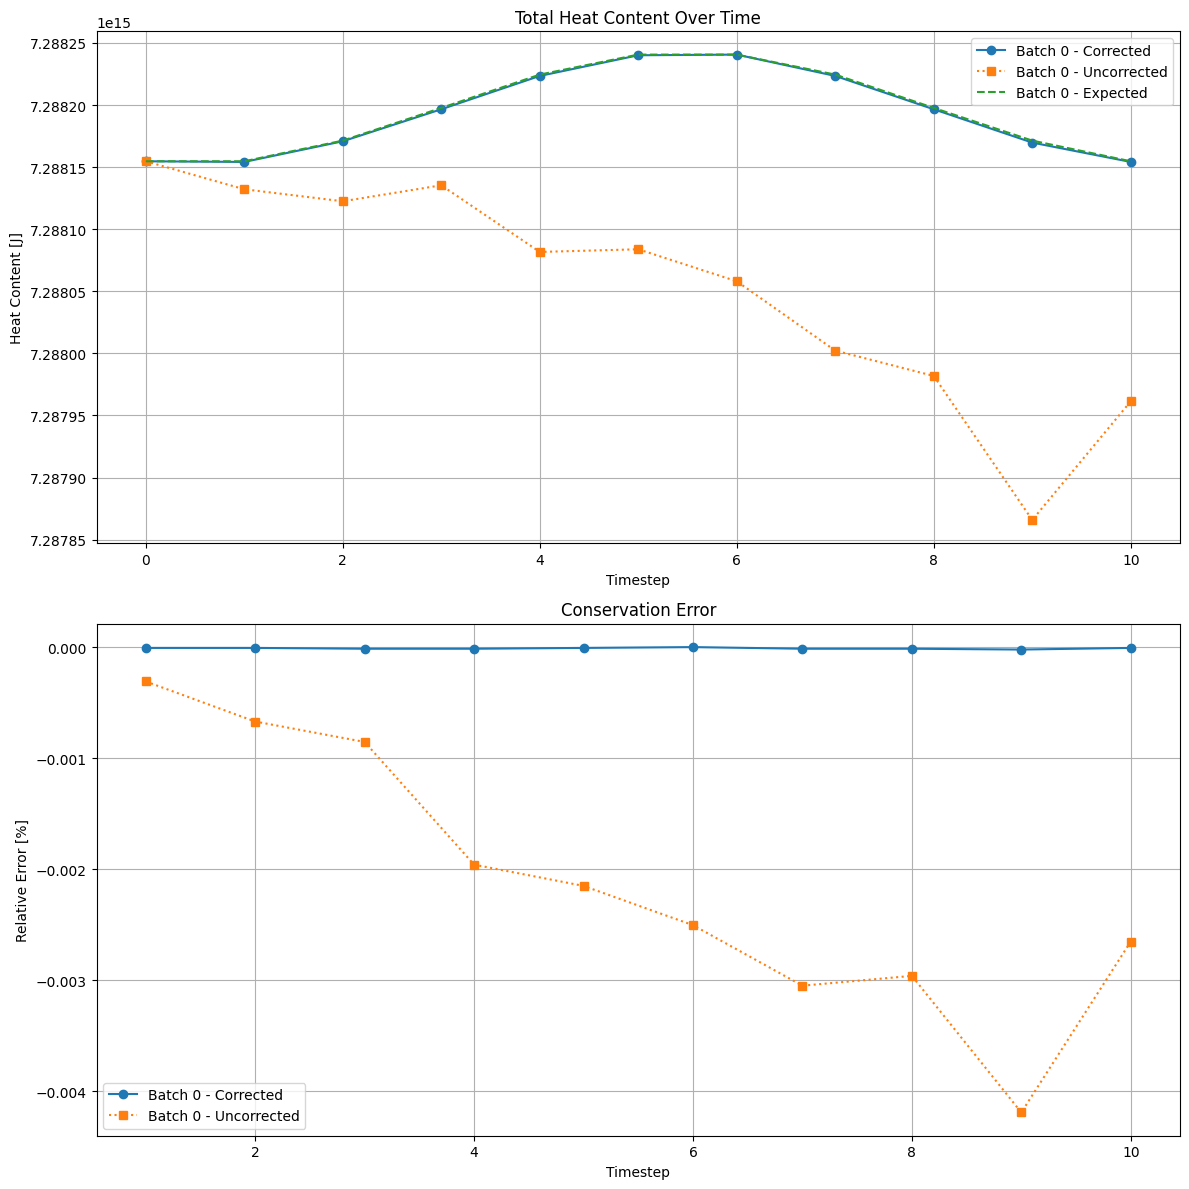


Batch 0 statistics:
Corrected - Maximum absolute error: 1.61e+09 J
Corrected - Maximum relative error: 2.21e-05%
Uncorrected - Maximum absolute error: 3.05e+11 J
Uncorrected - Maximum relative error: 4.19e-03%


In [39]:
def test_ocean_heat_rollout():
    # Create test grid
    batch_size = 1
    depth = 19
    lat = 180
    lon = 360
    n_timesteps = 10
    
    # Initialize fixer
    fixer = OceanHeatFixer()
    
    # Arrays to store heat content and expected changes
    heat_contents = torch.zeros((batch_size, n_timesteps+1), dtype=torch.float32)
    heat_contents_uncorrected = torch.zeros((batch_size, n_timesteps+1), dtype=torch.float32)
    expected_changes = torch.zeros((batch_size, n_timesteps), dtype=torch.float32)
    
    # Create initial state
    dz = torch.tensor([i*10.0 for i in range(1, 20)], dtype=torch.float32)
    # dz = dz / dz.sum() # Normalize
    T_current = 15.0 + torch.randn((batch_size, depth, lat, lon), dtype=torch.float32)
    T_current_uncorrected = T_current.clone()
    
    # Calculate initial heat content
    for b in range(batch_size):
        heat_contents[b, 0] = (RHO_0 * CP_SW * T_current[b] * dz.view(-1, 1, 1)).sum()
        heat_contents_uncorrected[b, 0] = heat_contents[b, 0].clone()
    
    # Rollout loop
    for t in range(n_timesteps):
        # Create "predicted" state with same random seed for both cases
        torch.manual_seed(t)  # Ensure same randomness for both cases
        T_pred = T_current + 0.1 * torch.randn_like(T_current)
        torch.manual_seed(t)  # Reset seed for uncorrected case
        T_pred_uncorrected = T_current_uncorrected + 0.1 * torch.randn_like(T_current_uncorrected)
        
        # Create surface heat flux
        surface_heat_flux = torch.sin(torch.tensor(2*np.pi*t/n_timesteps)) * \
                           torch.ones((batch_size, lat, lon), dtype=torch.float32)
        
        # Package inputs
        inputs = {
            'T_input': T_current,
            'T_pred': T_pred,
            'dz': dz,
            'surface_heat_flux': surface_heat_flux,
        }
        
        # Apply conservation
        T_corrected = fixer.forward(inputs)
        
        # Store heat content and expected changes
        for b in range(batch_size):
            # Corrected heat content
            heat_contents[b, t+1] = (RHO_0 * CP_SW * T_corrected[b] * dz.view(-1, 1, 1)).sum()
            
            # Uncorrected heat content
            heat_contents_uncorrected[b, t+1] = (RHO_0 * CP_SW * T_pred_uncorrected[b] * 
                                                dz.view(-1, 1, 1)).sum()
            
            expected_changes[b, t] = surface_heat_flux[b].sum() * fixer.N_seconds
        
        # Update current states
        T_current = T_corrected
        T_current_uncorrected = T_pred_uncorrected
    
    # Plot results
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 12))
    times = np.arange(n_timesteps + 1)
    
    for b in range(batch_size):
        # Plot heat content
        axes[0].plot(times, heat_contents[b].numpy(), 
                    label=f'Batch {b} - Corrected', marker='o')
        axes[0].plot(times, heat_contents_uncorrected[b].numpy(),
                    label=f'Batch {b} - Uncorrected', marker='s', linestyle=':')
        
        # Plot expected heat content
        expected_heat = heat_contents[b, 0].numpy() + \
                       np.cumsum(expected_changes[b].numpy())
        axes[0].plot(times, np.concatenate([[heat_contents[b, 0].numpy()], expected_heat]), 
                    label=f'Batch {b} - Expected', linestyle='--')
    
    axes[0].set_title('Total Heat Content Over Time')
    axes[0].set_xlabel('Timestep')
    axes[0].set_ylabel('Heat Content [J]')
    axes[0].legend()
    axes[0].grid(True)
    
    # Plot relative errors
    for b in range(batch_size):
        expected_heat = heat_contents[b, 0].numpy() + \
                       np.cumsum(expected_changes[b].numpy())
        
        # Corrected errors
        errors_corrected = (heat_contents[b, 1:].numpy() - expected_heat) / expected_heat * 100
        axes[1].plot(times[1:], errors_corrected, 
                    label=f'Batch {b} - Corrected', marker='o')
        
        # Uncorrected errors
        errors_uncorrected = (heat_contents_uncorrected[b, 1:].numpy() - expected_heat) / expected_heat * 100
        axes[1].plot(times[1:], errors_uncorrected,
                    label=f'Batch {b} - Uncorrected', marker='s', linestyle=':')
    
    axes[1].set_title('Conservation Error')
    axes[1].set_xlabel('Timestep')
    axes[1].set_ylabel('Relative Error [%]')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    for b in range(batch_size):
        expected_heat = heat_contents[b, 0].numpy() + \
                       np.cumsum(expected_changes[b].numpy())
        
        # Corrected errors
        max_error_corrected = np.max(np.abs(heat_contents[b, 1:].numpy() - expected_heat))
        max_relative_error_corrected = np.max(np.abs(heat_contents[b, 1:].numpy() - expected_heat) / 
                                            np.abs(expected_heat) * 100)
        
        # Uncorrected errors
        max_error_uncorrected = np.max(np.abs(heat_contents_uncorrected[b, 1:].numpy() - expected_heat))
        max_relative_error_uncorrected = np.max(np.abs(heat_contents_uncorrected[b, 1:].numpy() - expected_heat) / 
                                              np.abs(expected_heat) * 100)
        
        print(f"\nBatch {b} statistics:")
        print(f"Corrected - Maximum absolute error: {max_error_corrected:.2e} J")
        print(f"Corrected - Maximum relative error: {max_relative_error_corrected:.2e}%")
        print(f"Uncorrected - Maximum absolute error: {max_error_uncorrected:.2e} J")
        print(f"Uncorrected - Maximum relative error: {max_relative_error_uncorrected:.2e}%")

if __name__ == "__main__":
    test_ocean_heat_rollout()